In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
exp = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/exponential_fit_baseline_norm.csv", index_col = 0)
exp = exp[["ADseq", "t_half_model_empirical", "obs_max"]]
exp = exp.rename(columns = {"t_half_model_empirical" : "t_half_exp", 
                            "obs_max" : "obs_max_exp"})
exp

,ADseq,t_half_exp,obs_max_exp
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,7.935872,1.235476
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,4.629259,2.170885
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,4.268537,1.993799
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,4.388778,2.505392
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,15.090180,0.875806
...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,9.919840,1.482613
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,15.210421,1.104135
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,3.667335,4.196226
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,4.268537,2.685433


In [3]:
log = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/logistic_fit_baseline_norm.csv", index_col = 0)
log = log[["ADseq", "t_half", "observed_strength"]]
log = log.rename(columns = {"t_half" : "t_half_log", 
                            "observed_strength" : "obs_max_log"})
log

,ADseq,t_half_log,obs_max_log
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,8.498498,1.143164
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,4.834835,1.921117
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,4.384384,1.870561
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,4.444444,2.323555
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,15.165165,0.883255
...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,9.849850,1.426421
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,14.534535,1.069386
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,3.963964,3.861668
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,5.165165,2.465108


In [4]:
hill = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/hill_fit_baseline_norm.csv", index_col = 0)
hill = hill[["ADseq", "t_half_obs", "obs_max"]]
hill = hill.rename(columns = {"t_half_obs" : "t_half_hill", 
                            "obs_max" : "obs_max_hill"})
hill

,ADseq,t_half_hill,obs_max_hill
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,8.116232,1.201293
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,4.629259,2.243477
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,4.208417,2.014279
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,4.388778,2.522634
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,14.488978,0.867616
...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,9.559118,1.447129
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,14.248497,1.065817
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,2.224449,4.371099
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,4.569138,2.687277


In [5]:
first_passage_pval_class = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/first_passage_pval_class.csv", index_col = 0)
first_passage_pval_class

,ADseq,first_pass_time,max_activity
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.210488
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,5,2.359397
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,5,2.032776
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,5,2.527994
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,30,0.890615
...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,10,1.469611
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,30,1.090644
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5,4.379672
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,5,2.794890


In [6]:
# first_passage_DBD = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/first_passage_DBD.csv", index_col = 0)
# first_passage_DBD = first_passage_DBD.rename(columns = {"first_pass_time" : "first_pass_time_DBD", "max_activity" : "max_activity_DBD"})
# first_passage_DBD

In [7]:
merged = pd.merge(exp, log, how = 'outer')
merged = pd.merge(merged, hill, how = 'outer')
merged = pd.merge(merged, first_passage_pval_class, how = 'outer')
#merged = pd.merge(merged, first_passage_DBD, how = 'outer')
merged

,ADseq,t_half_exp,obs_max_exp,t_half_log,obs_max_log,t_half_hill,obs_max_hill,first_pass_time,max_activity
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,7.935872,1.235476,8.498498,1.143164,8.116232,1.201293,10,1.210488
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,4.629259,2.170885,4.834835,1.921117,4.629259,2.243477,5,2.359397
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,4.268537,1.993799,4.384384,1.870561,4.208417,2.014279,5,2.032776
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,4.388778,2.505392,4.444444,2.323555,4.388778,2.522634,5,2.527994
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,15.090180,0.875806,15.165165,0.883255,14.488978,0.867616,30,0.890615
...,...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,9.919840,1.482613,9.849850,1.426421,9.559118,1.447129,10,1.469611
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,15.210421,1.104135,14.534535,1.069386,14.248497,1.065817,30,1.090644
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,3.667335,4.196226,3.963964,3.861668,2.224449,4.371099,5,4.379672
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,4.268537,2.685433,5.165165,2.465108,4.569138,2.687277,5,2.794890


# Metric comparison

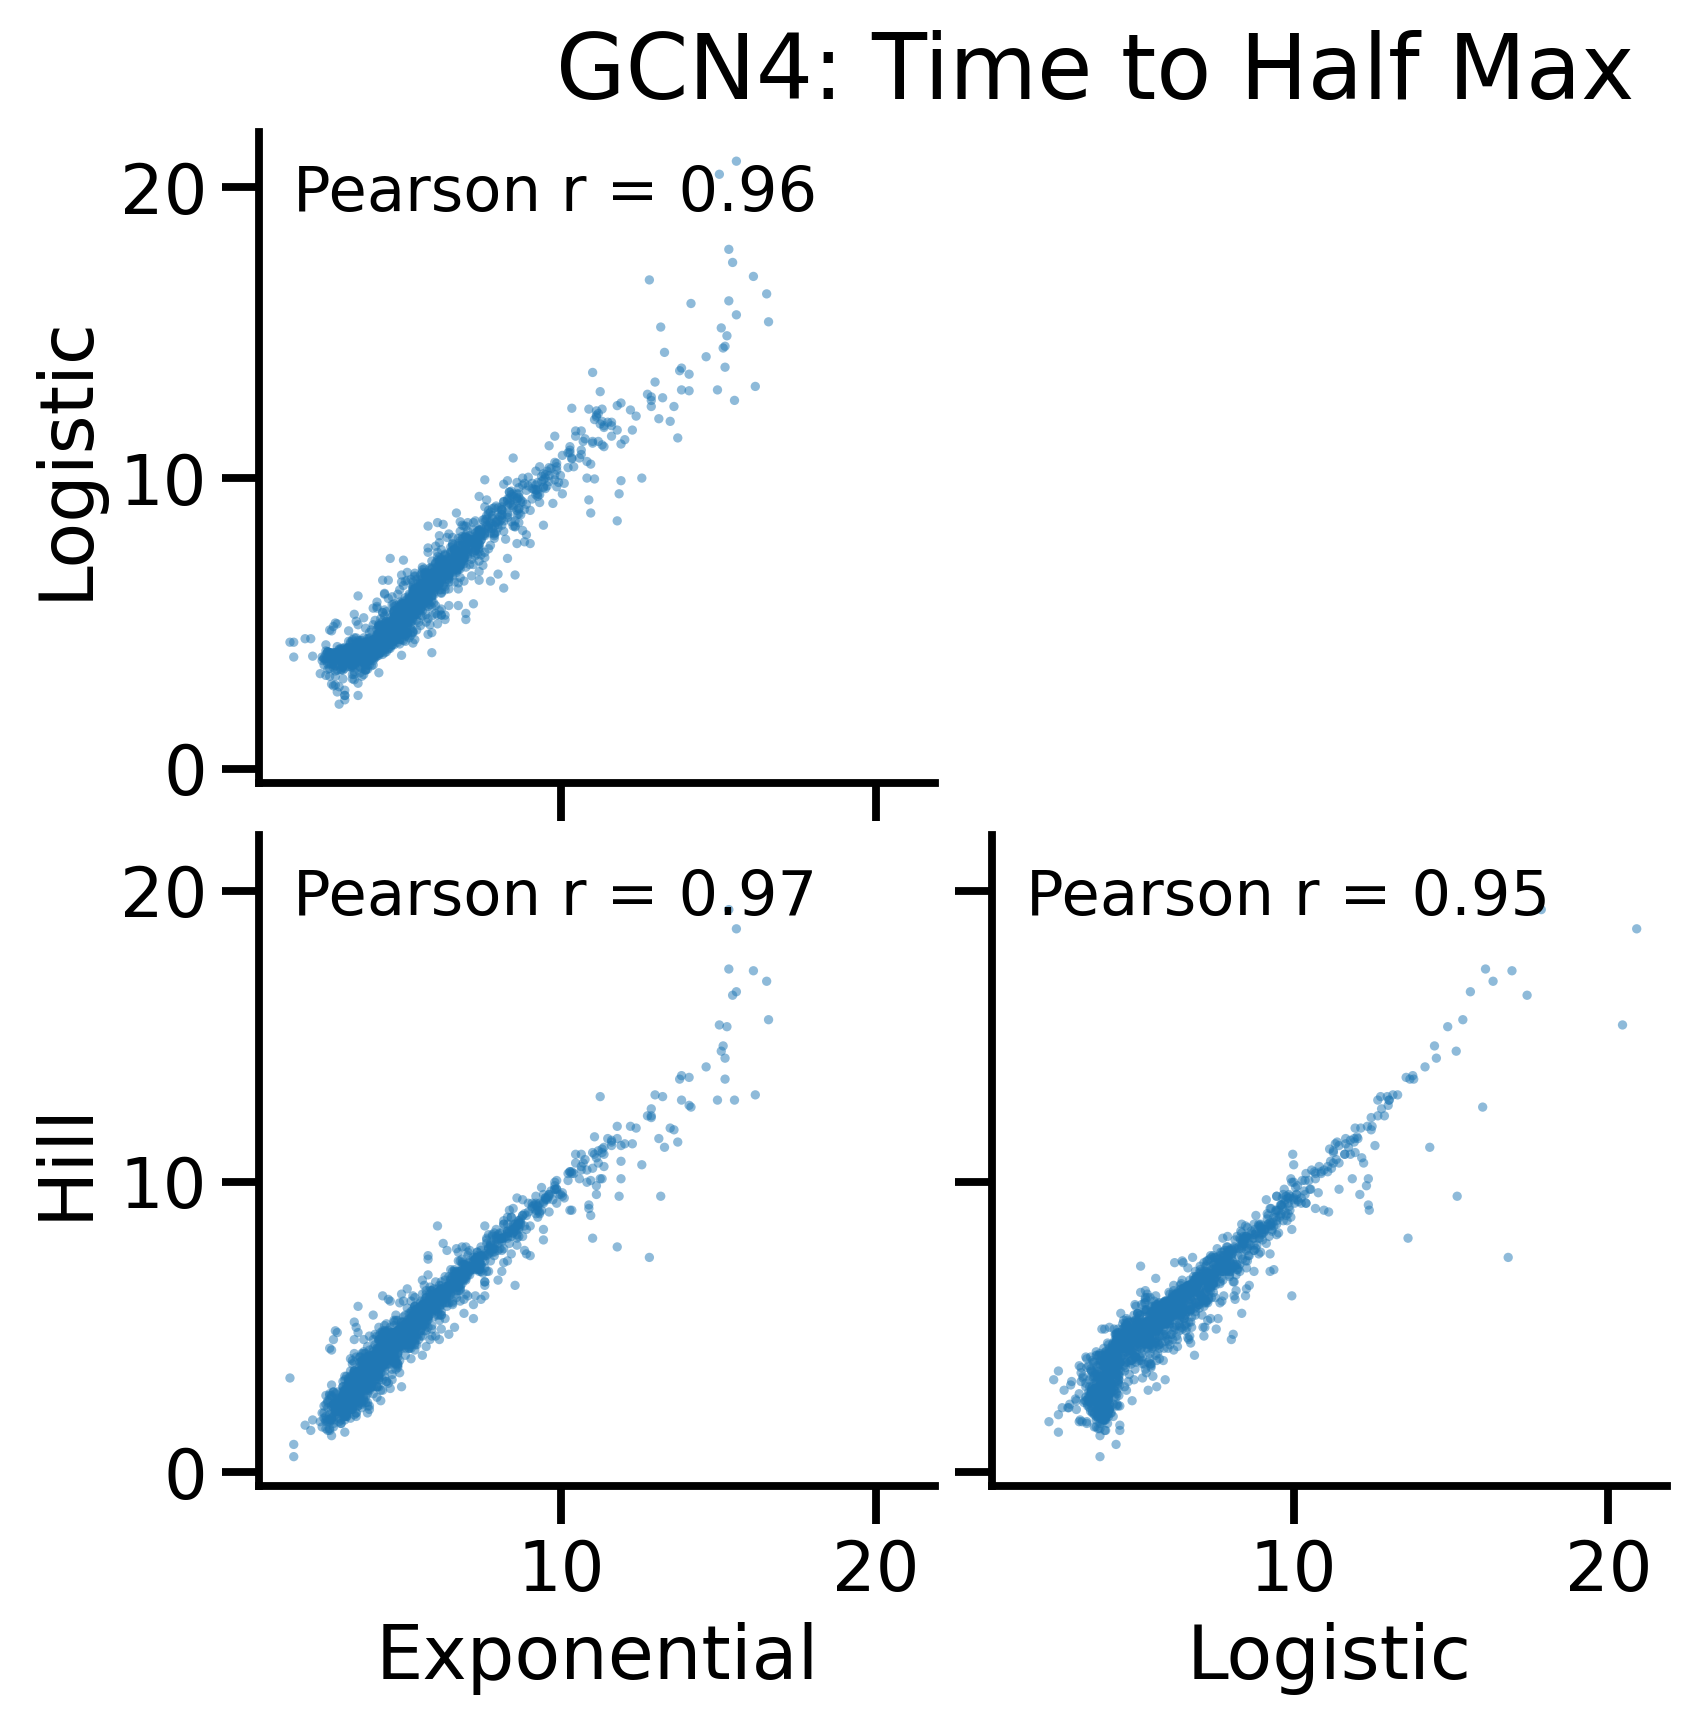

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_context('talk')

cols = ["t_half_exp", "t_half_log", "t_half_hill", ]
df = merged[cols].dropna()
df.columns = ["Exponential", "Logistic", "Hill"]
cols = df.columns.tolist()  # <-- sync cols to new names

fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True, dpi  =300)

for i, y_var in enumerate(cols):
    for j, x_var in enumerate(cols):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.5, s=5, edgecolor="none")

        r, p = stats.pearsonr(df[x_var], df[y_var])
        ax.annotate(f"Pearson r = {r:.2f}", xy=(0.05, 0.95), xycoords="axes fraction",
                    ha="left", va="top", fontsize='small')

        if j == 0:
            ax.set_ylabel(y_var)
        if i == len(cols) - 1:
            ax.set_xlabel(x_var)

plt.suptitle("GCN4: Time to Half Max", y = 0.7, x = 0.45)
sns.despine()
plt.tight_layout(pad = 0.2)
plt.show()

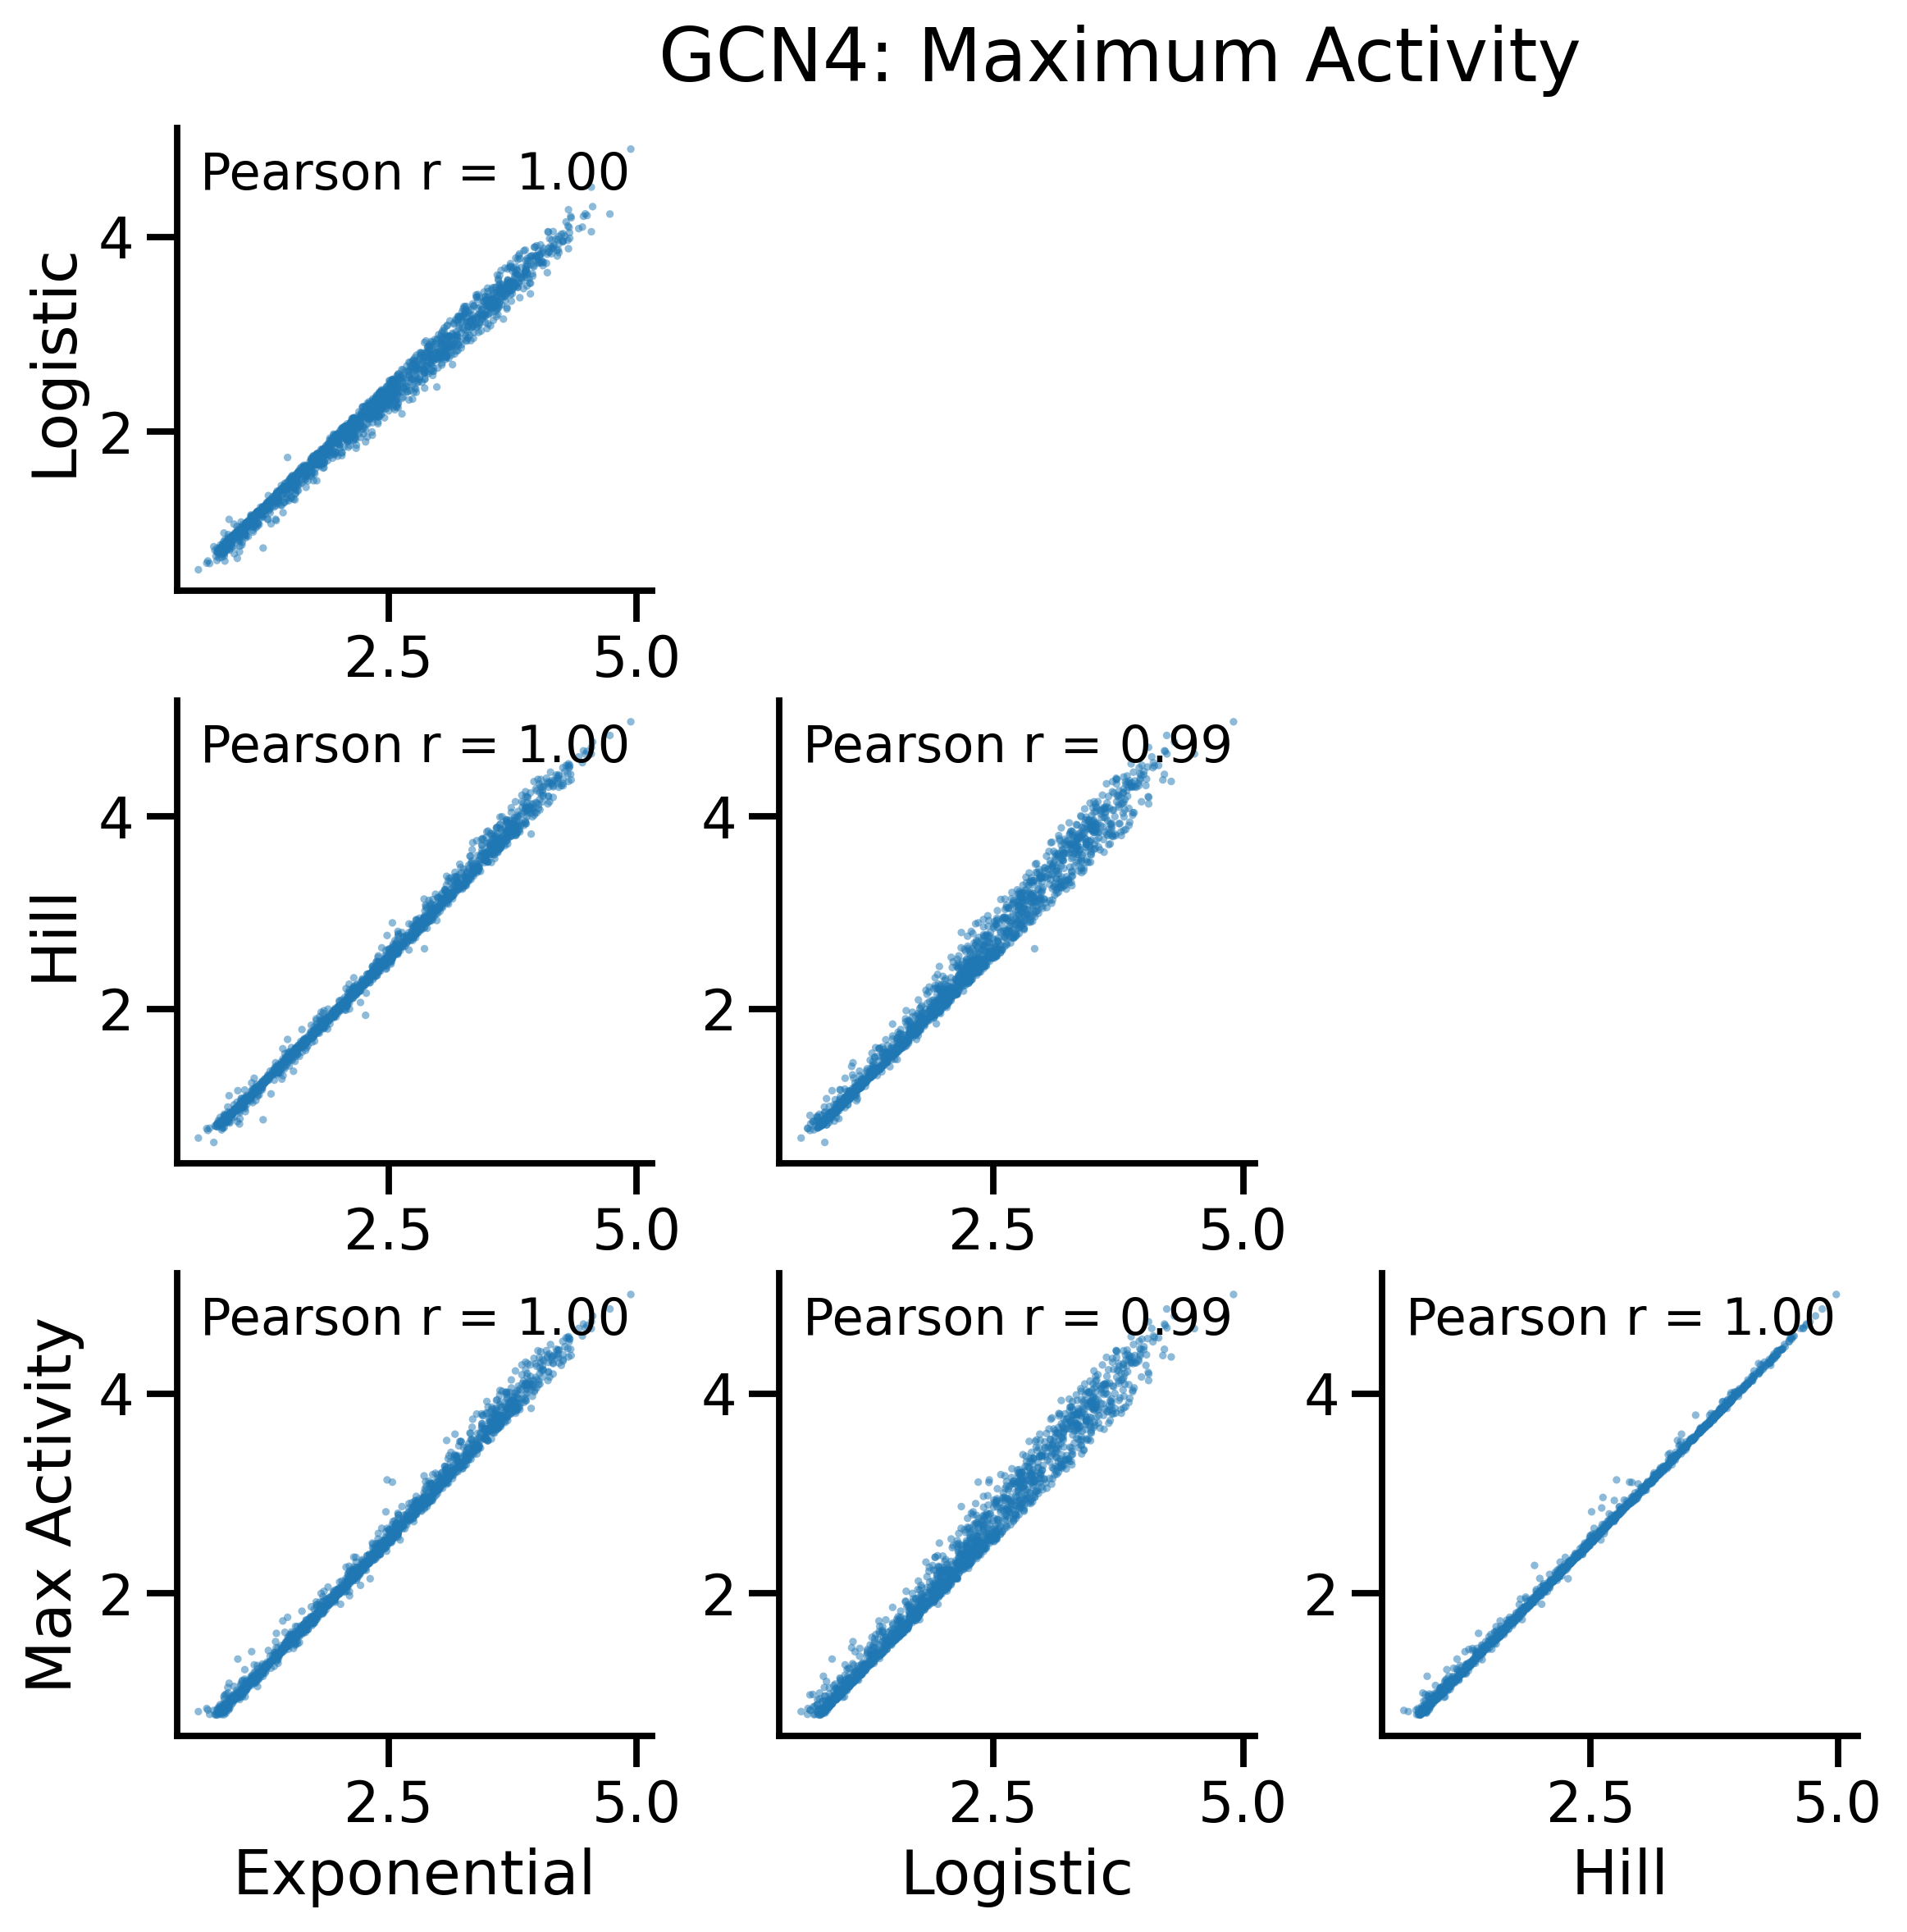

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_context('talk')

cols = ["obs_max_exp", "obs_max_log", "obs_max_hill", "max_activity"]
df = merged[cols].dropna()
df.columns = ["Exponential", "Logistic", "Hill", "Max Activity"]
cols = df.columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(10, 10), sharex=False, sharey=False, dpi = 300)

for i, y_var in enumerate(cols):
    for j, x_var in enumerate(cols):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.5, s=5, edgecolor="none")

        r, p = stats.pearsonr(df[x_var], df[y_var])
        ax.annotate(f"Pearson r = {r:.2f}", xy=(0.05, 0.95), xycoords="axes fraction",
                    ha="left", va="top", fontsize='small')

        if j == 0:
            ax.set_ylabel(y_var)
        else:
            ax.set_ylabel("")
        if i == len(cols) - 1:
            ax.set_xlabel(x_var)
        else:
            ax.set_xlabel("")

plt.suptitle("GCN4: Maximum Activity", y=0.77, x=0.45)
sns.despine()
plt.tight_layout(pad=0.2)
plt.show()

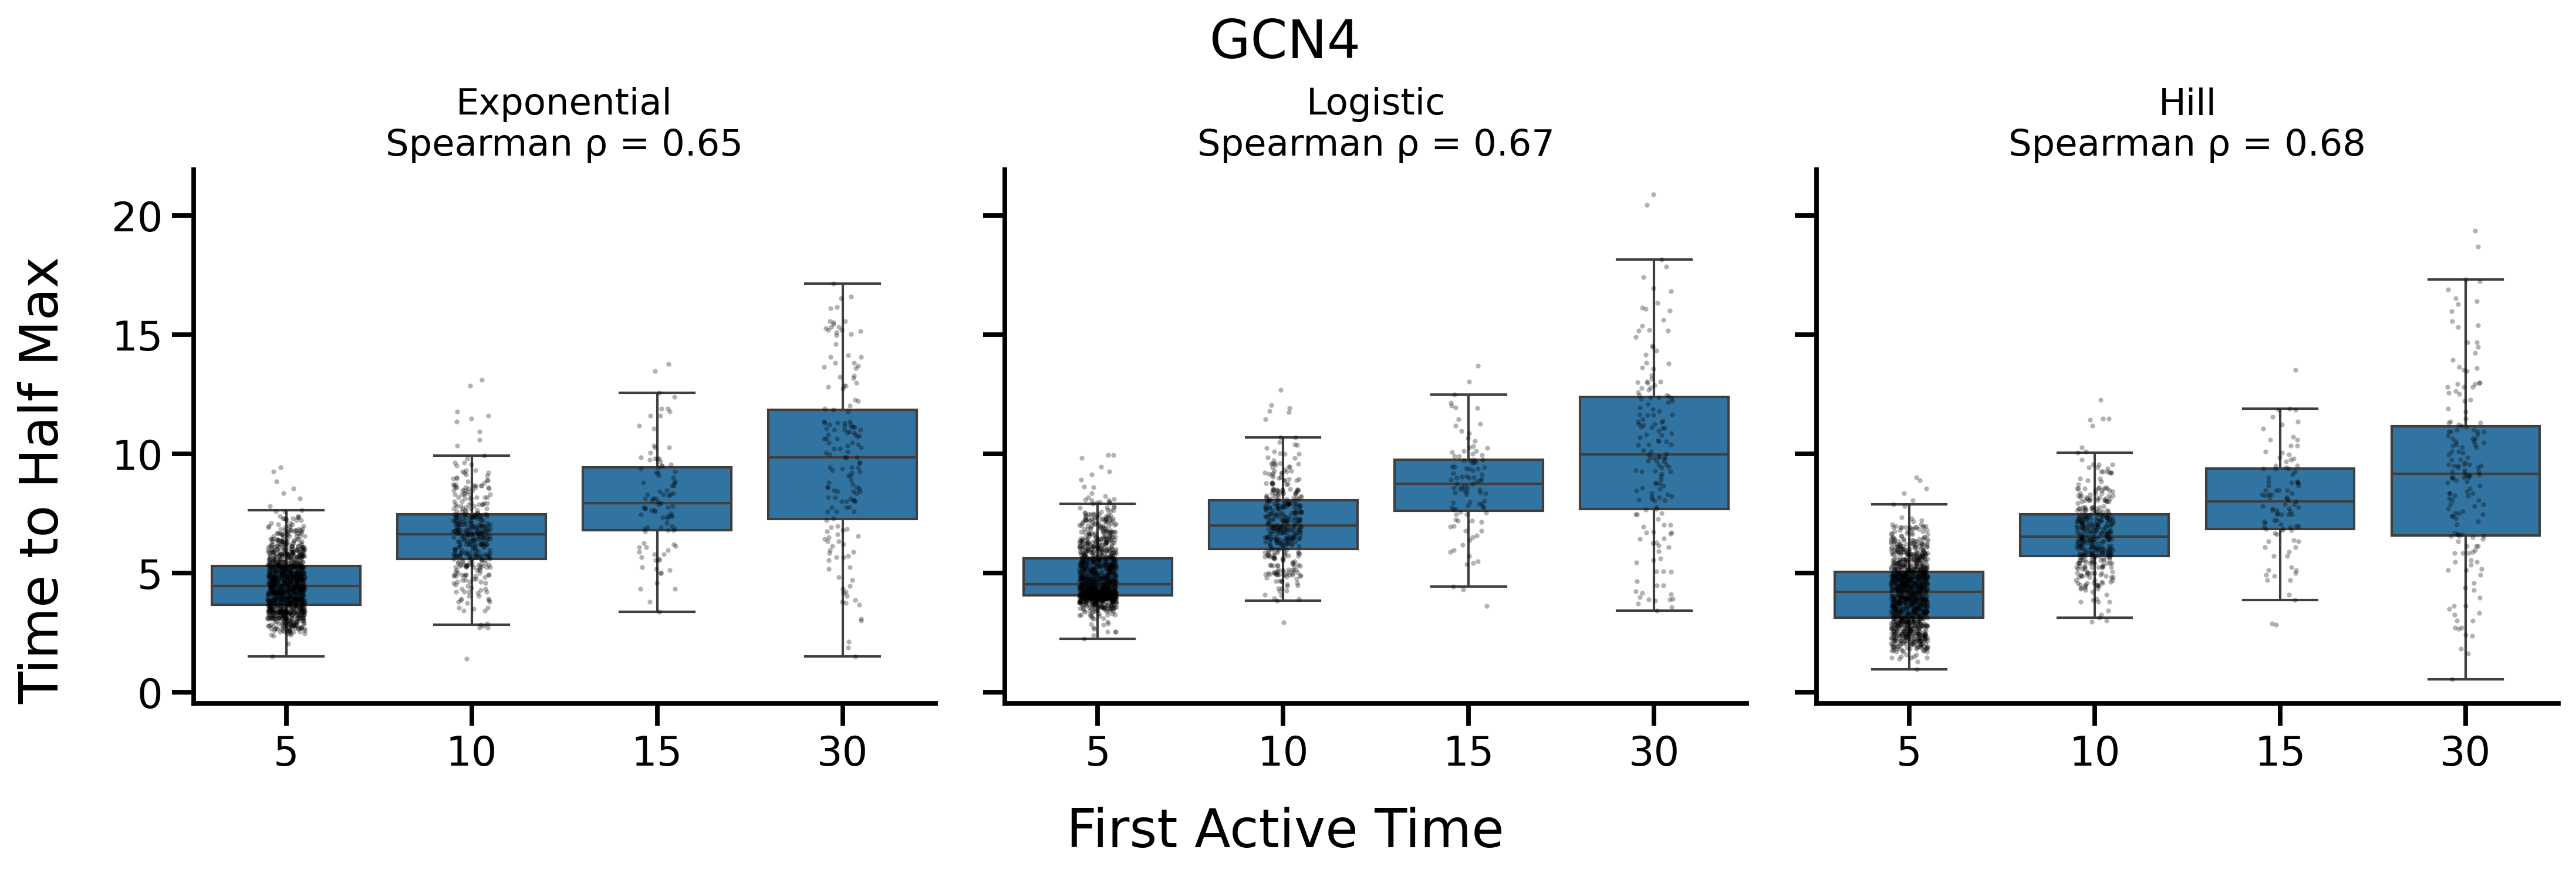

In [10]:
models = [
    ("t_half_exp", "Exponential"),
    ("t_half_log", "Logistic"),
    ("t_half_hill", "Hill"),
]

for col_time, title in zip(
    ["first_pass_time"],
    ["P-Val Classes"]
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, dpi=300)
    df = merged.copy()

    df = df.dropna(subset=[col_time])
    df[col_time] = df[col_time].astype(int)

    for ax, (col, subplot_title) in zip(axes, models):
        sns.boxplot(
            x=df[col_time], 
            y=df[col], 
            ax=ax,
            color="C0",
            fliersize=0
        )
        sns.stripplot(
            x=df[col_time], 
            y=df[col], 
            ax=ax,
            color="black",
            alpha=0.3,
            size=2
        )

        # correlation
        from scipy.stats import spearmanr
        subdf = df[[col_time, col]].dropna()
        r, p = spearmanr(subdf[col_time], subdf[col])

        ax.set_title(f"{subplot_title}\nSpearman ρ = {r:.2f}", fontsize='small')

        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.supxlabel("First Active Time", y=0.07)
    fig.supylabel("Time to Half Max")

    sns.despine()
    plt.tight_layout()
    plt.suptitle("GCN4", y=1.025)
    plt.show()

# Summary

In [11]:
merged

,ADseq,t_half_exp,obs_max_exp,t_half_log,obs_max_log,t_half_hill,obs_max_hill,first_pass_time,max_activity
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,7.935872,1.235476,8.498498,1.143164,8.116232,1.201293,10,1.210488
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,4.629259,2.170885,4.834835,1.921117,4.629259,2.243477,5,2.359397
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,4.268537,1.993799,4.384384,1.870561,4.208417,2.014279,5,2.032776
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,4.388778,2.505392,4.444444,2.323555,4.388778,2.522634,5,2.527994
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,15.090180,0.875806,15.165165,0.883255,14.488978,0.867616,30,0.890615
...,...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,9.919840,1.482613,9.849850,1.426421,9.559118,1.447129,10,1.469611
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,15.210421,1.104135,14.534535,1.069386,14.248497,1.065817,30,1.090644
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,3.667335,4.196226,3.963964,3.861668,2.224449,4.371099,5,4.379672
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,4.268537,2.685433,5.165165,2.465108,4.569138,2.687277,5,2.794890


In [12]:
import numpy as np
import pandas as pd

models = ["exp", "log", "hill"]

# --- keep only full rows ---
cols_needed = [f"{p}_{m}" for m in models for p in ["t_half", "obs_max"]]
filtered = merged.dropna(subset=cols_needed).copy()

# --- aggregate ---
filtered["mean_t_half"] = filtered[[f"t_half_{m}" for m in models]].mean(axis=1)
filtered["mean_max"] = filtered[[f"obs_max_{m}" for m in models]].mean(axis=1)


# ===============================
# helper: pick 3 representative points
# ===============================
def pick_three(df, sort_col):
    df = df.sort_values(sort_col).reset_index(drop=True)
    n = len(df)

    if n < 3:
        return df  # fallback

    return pd.concat([
        df.iloc[[0]],
        df.iloc[[n // 2]],
        df.iloc[[-1]]
    ])


# ===============================
# 1. SAME strength, DIFFERENT speed
# ===============================
A_target = filtered["mean_max"].median()
A_tol = filtered["mean_max"].std() * 0.2

similar_A = filtered[
    (filtered["mean_max"] >= A_target - A_tol) &
    (filtered["mean_max"] <= A_target + A_tol)
].copy()

seq_simA_diffk = pick_three(similar_A, "mean_t_half")


# ===============================
# 2. SAME speed, DIFFERENT strength
# ===============================
k_target = filtered["mean_t_half"].median()
k_tol = filtered["mean_t_half"].std() * 0.2

similar_k = filtered[
    (filtered["mean_t_half"] >= k_target - k_tol) &
    (filtered["mean_t_half"] <= k_target + k_tol)
].copy()

seq_simk_diffA = pick_three(similar_k, "mean_max")


# --- combine ---
selected = pd.concat([seq_simA_diffk, seq_simk_diffA]).drop_duplicates("ADseq")
selected_adseqs = selected["ADseq"].tolist()
selected_adseqs

['PGTVSPRDLFIDASAPPSATFTDLSTPPLDTPGYFSQNTS',
 'IGTDLCGTTVSPSEVTMNPSMPTPTFSSPYLFDSPSEGYE',
 'GDPWYPLFPPEDQFEVPKIEDSSPLLPEEELEVSEALRTS',
 'FTTDPQPPWLPSSSSSLPAQSPQHKSHQDFSLPDPQPQPH',
 'GQWLALFPHPSSIDFDFNSFHQSFSSPPPHQPPTQLVAPP',
 'FACSLLTASFALDNLFDLPLDFGADDVTKDVSLFESVGYS']

In [13]:
from scipy.stats import pearsonr, spearmanr

def plot_all_model_speed_strength(selected_adseqs = None):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, dpi=300)
    title_dict = {"exp": "Exponential", "log": "Logistic", "hill": "Hill"}
    
    for ax, model in zip(axs, ["exp", "log", "hill"]):
        ax.set_title(title_dict[model])
        sns.scatterplot(data=merged, x=f"t_half_{model}", y=f"obs_max_{model}",
                        ax=ax, alpha=0.5, edgecolor='none', s=5)
    
        xy = merged[[f"t_half_{model}", f"obs_max_{model}"]].dropna()
        r, _ = pearsonr(xy.iloc[:, 0], xy.iloc[:, 1])
        rho, _ = spearmanr(xy.iloc[:, 0], xy.iloc[:, 1])
        ax.annotate(f"Spearman r = {r:.2f}\nPearson ρ = {rho:.2f}", xy=(0.95, 0.95),
                    xycoords="axes fraction", fontsize='small', ha='right', va='top', color = 'goldenrod')

        if selected_adseqs:
            for ad in selected_adseqs:
                row = merged[merged["ADseq"] == ad]
                
                x = row[f"t_half_{model}"].values[0]
                y = row[f"obs_max_{model}"].values[0]
        
                ax.scatter(
                    x, y,
                    color='red',
                    s=160,
                    marker="*",
                    edgecolor="red",
                    linewidth=0.7,
                    zorder=10
                )
    
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    plt.tight_layout()
    fig.supxlabel("Time to Half Max", y=-0.03)
    fig.supylabel("Observed\nModeled Max", x=-0.02, ha='center')
    fig.suptitle("GCN4", y=1.05)
    sns.despine()

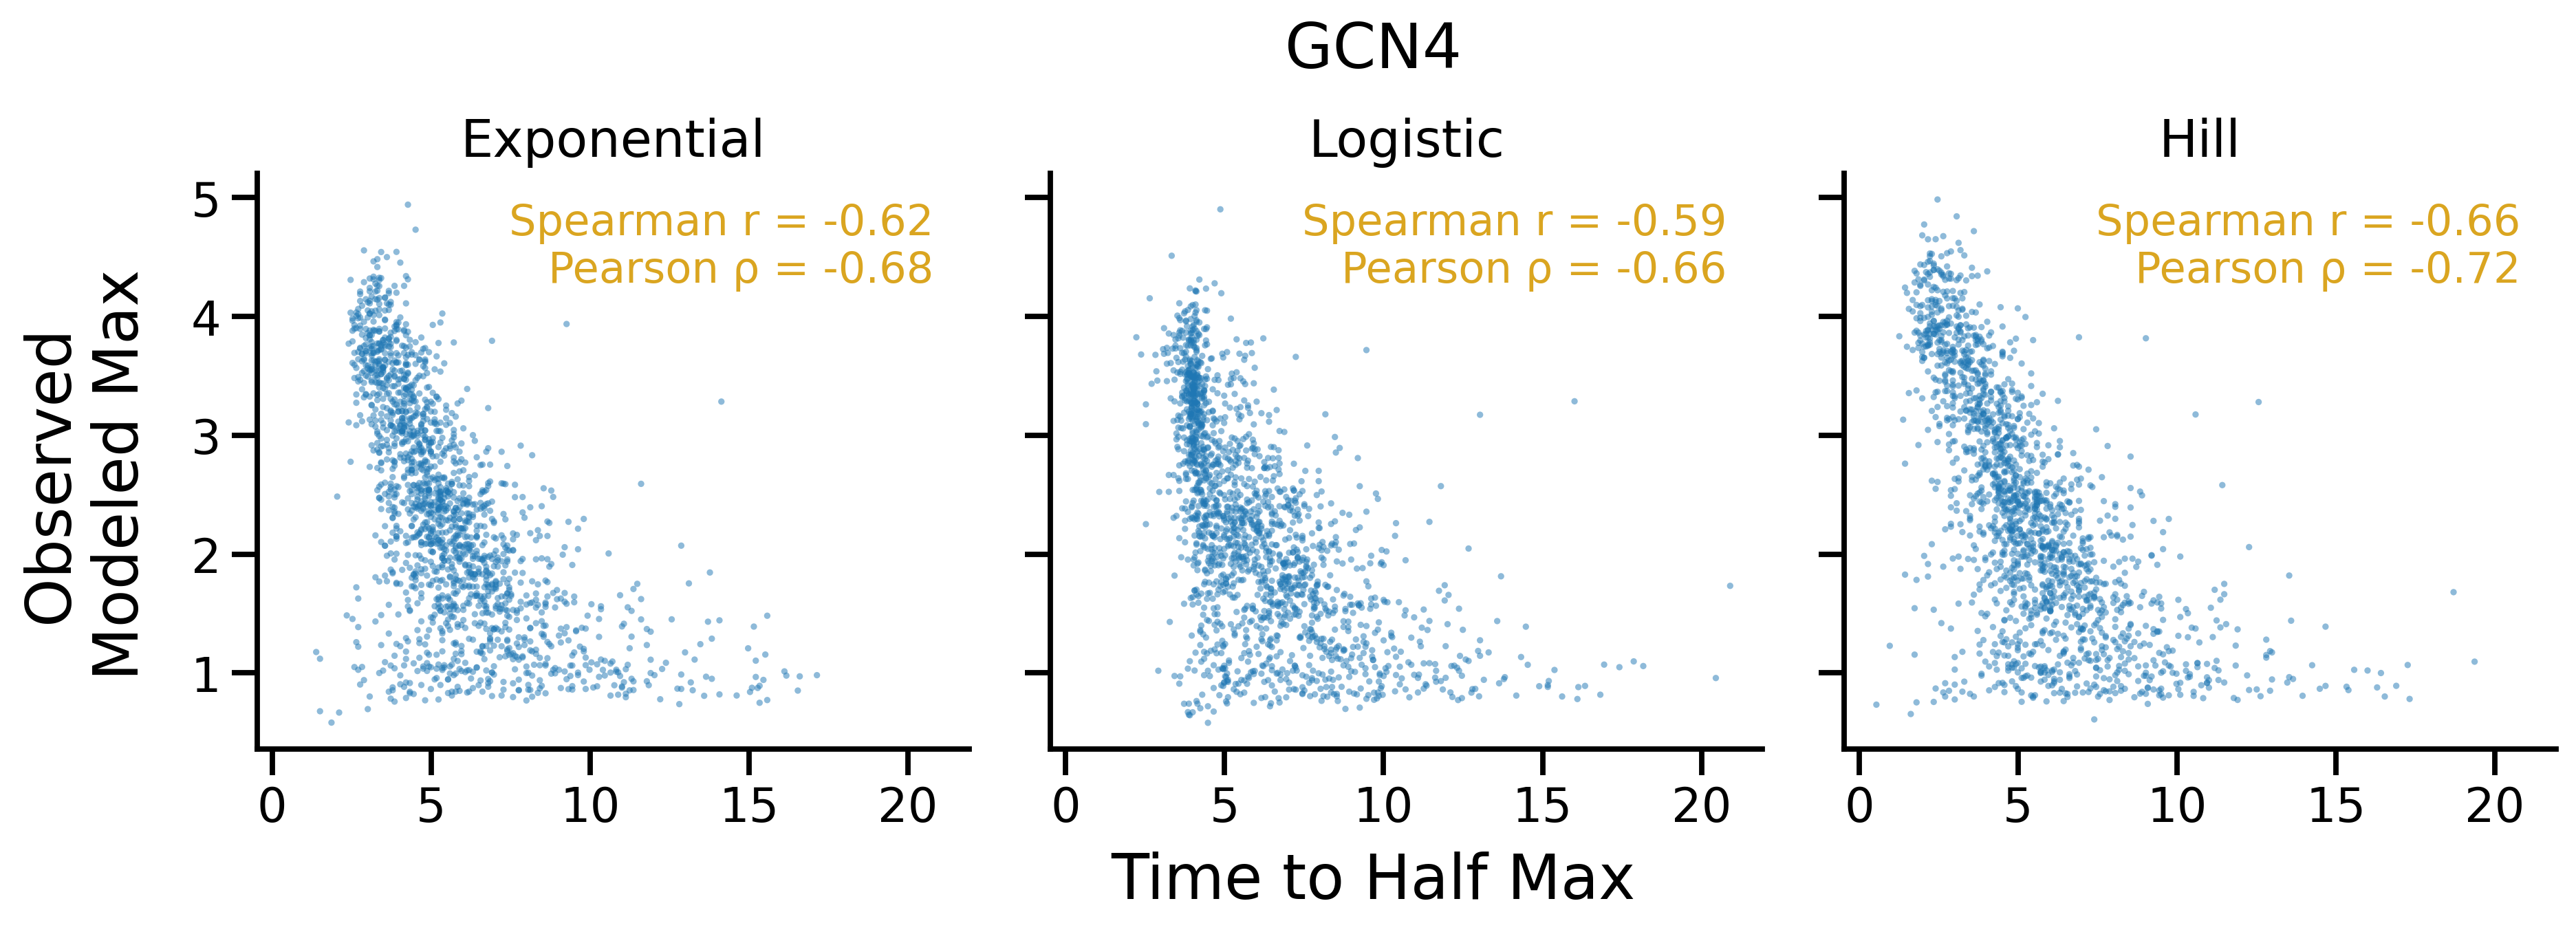

In [14]:
plot_all_model_speed_strength()

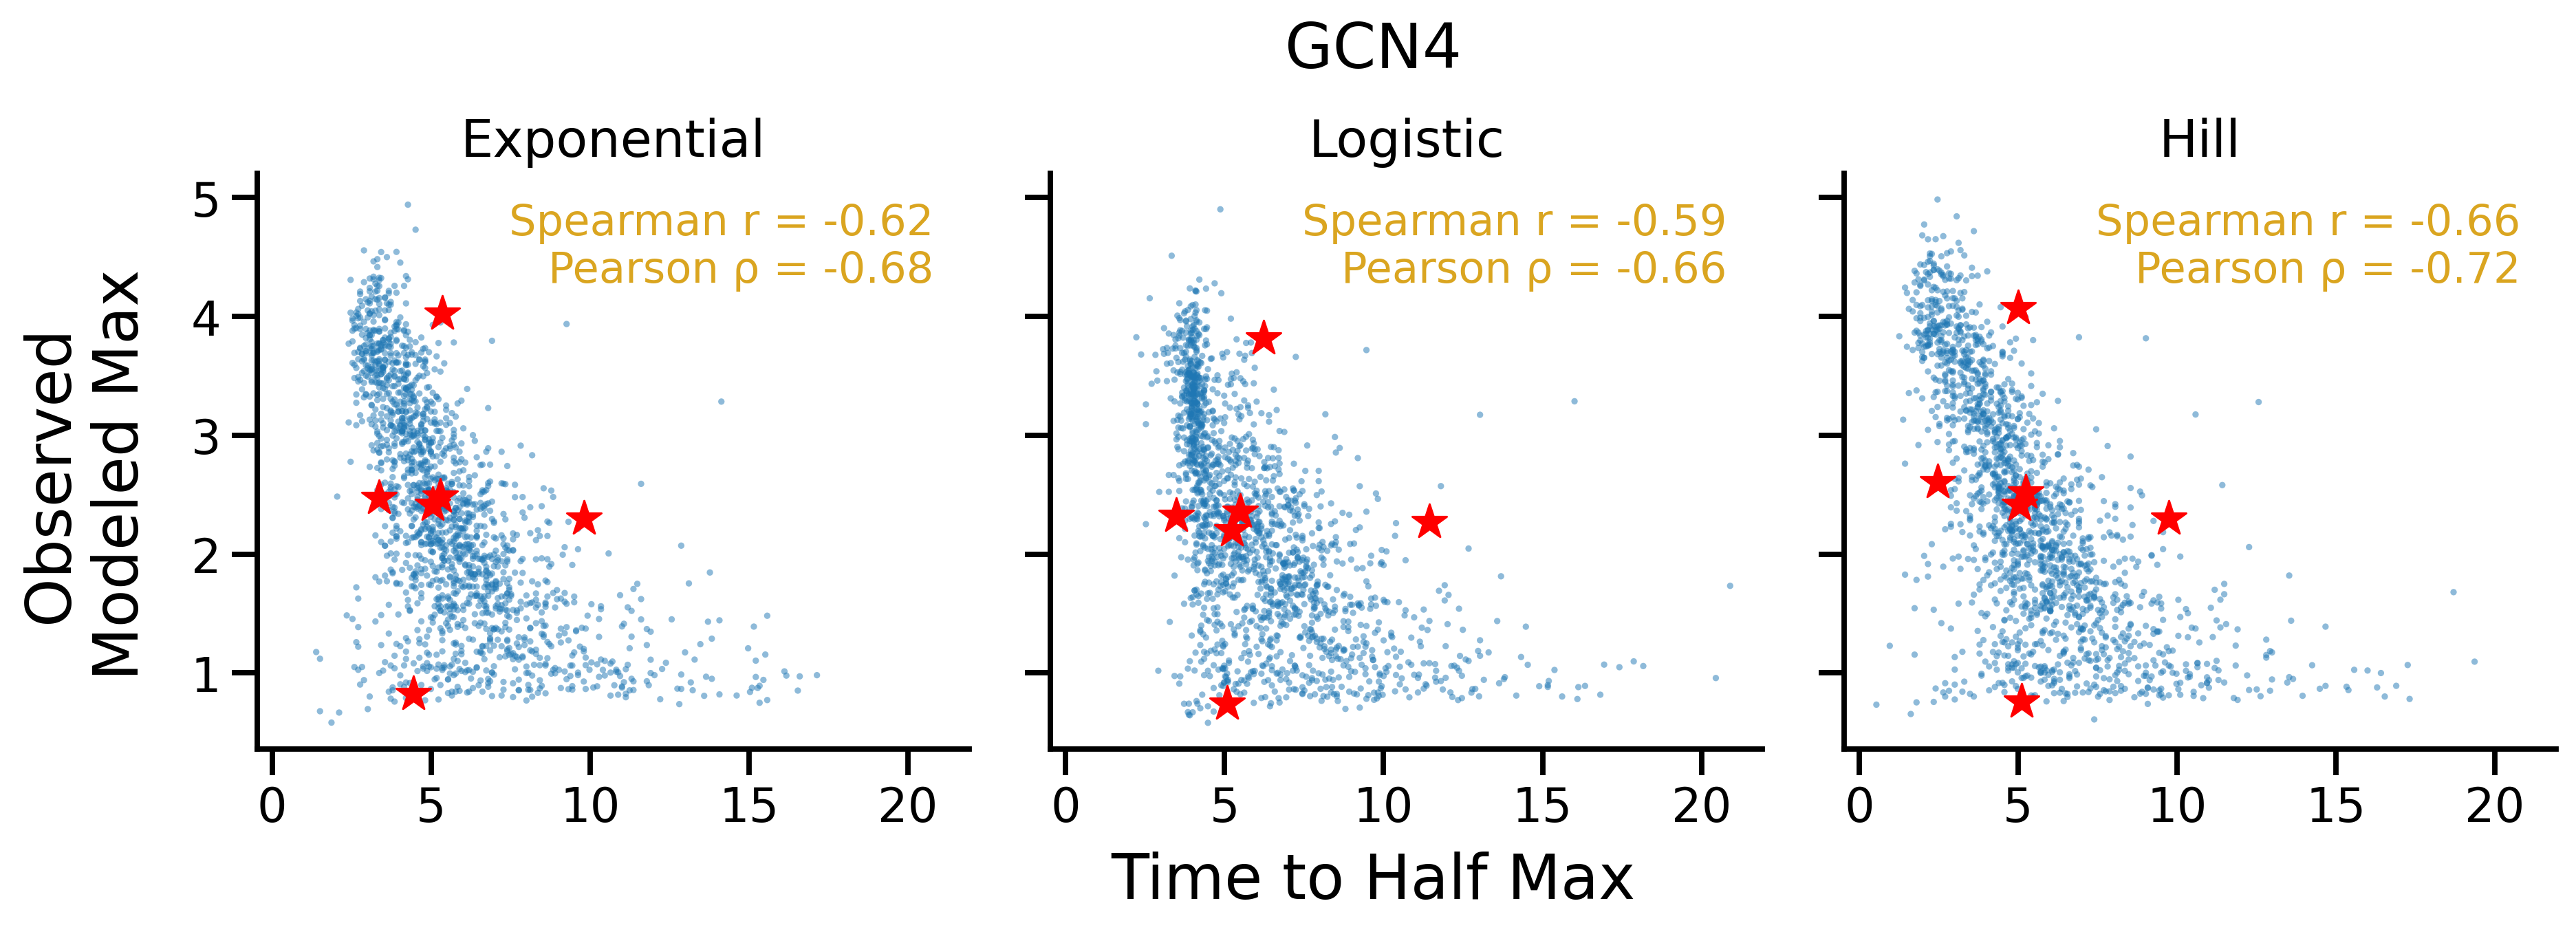

In [15]:
plot_all_model_speed_strength(selected_adseqs)

In [16]:
activities = pd.read_csv("../../../output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities['mean'] = activities["activity"]
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm,mean
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087,0.603252
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710,0.849635
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861,1.384974
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790,1.590645
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829,1.813740
...,...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201,0.317346
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516,2.505254
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259,3.162542
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125,3.419411


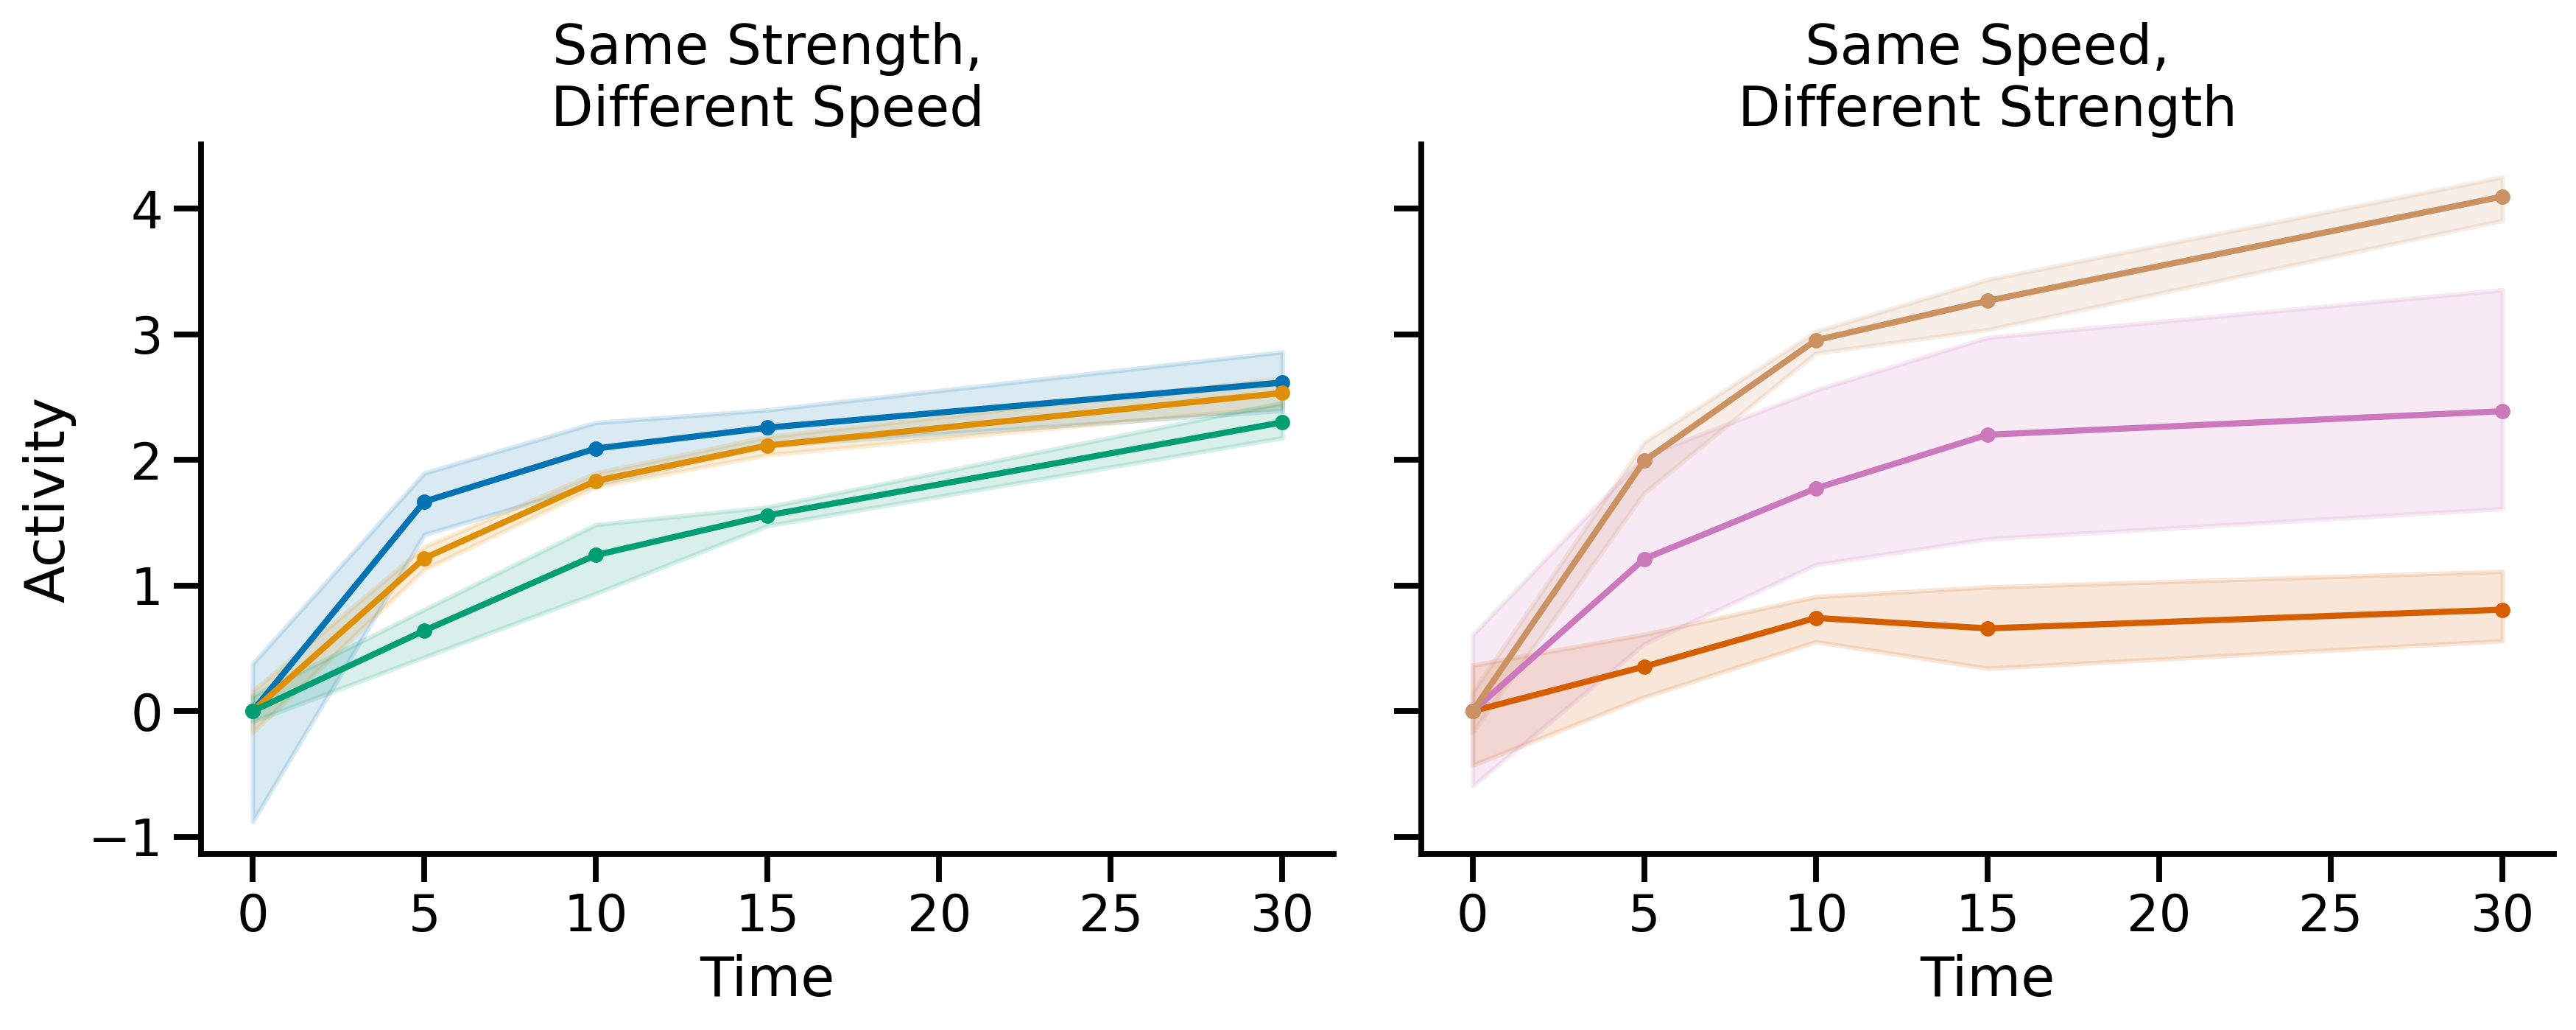

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df = activities  # trajectory df

plot_df = df[df["ADseq"].isin(selected_adseqs)].copy()
plot_df = plot_df.sort_values(["ADseq", "time"])

# stable colors
colors = dict(zip(selected_adseqs, sns.color_palette("colorblind", n_colors=len(selected_adseqs))))

# --- enforce grouping explicitly (IMPORTANT) ---
group_speed = selected_adseqs[:3]   # same strength, different speed
group_strength = selected_adseqs[3:]  # same speed, different strength

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

panels = [
    (axs[0], group_speed, "Same Strength,\nDifferent Speed"),
    (axs[1], group_strength, "Same Speed,\nDifferent Strength"),
]

for ax, group, title in panels:

    for ad in group:
        g = plot_df[plot_df["ADseq"] == ad].sort_values("time")

        t = g["time"].values
        y = g["activity_norm"].values
        lo = g["ci_low_norm"].values
        hi = g["ci_hi_norm"].values

        c = colors[ad]

        # CI band
        ax.fill_between(t, lo, hi, color=c, alpha=0.15)

        # trajectory
        ax.plot(
            t, y,
            color=c,
            linewidth=2,
            marker="o",
            markersize=4,
            label=ad[:6]
        )

    ax.set_title(title)
    ax.set_xlabel("Time")

# shared y-axis
axs[0].set_ylabel("Activity")

# styling
for ax in axs:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()